# Volatility Targeting Strategy — EWMA vs GARCH
This notebook explores a volatility-scaled trading approach using EWMA (RiskMetrics-style) and GARCH(1,1) forecasts on SPY returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model
import os

In [4]:
# paths + params
PATH_SPY = 'data/SPY_2010_2024.xlsx'
trading_days = 252
target_ann_vol = 0.10
target_daily_vol = target_ann_vol / np.sqrt(trading_days)
lam = 0.94
max_leverage = 2
min_leverage = 0
tc_bps = 5
slip_bps = 1

In [5]:
# load + prep
df = pd.read_excel(PATH_SPY)
df = df.set_index('Date')
df.index = pd.to_datetime(df.index)
df = df.sort_index()
if 'Close Price' in df.columns:
    prices = df['Close Price']
else:
    prices = df.iloc[:,0]
ret = np.log(prices / prices.shift(1)).dropna()
df = pd.DataFrame({'Price': prices, 'Return': ret}).dropna()

In [6]:
# EWMA
sigma2_rm = np.zeros(len(df))
sigma2_rm[0] = ret.var()
for i in range(1, len(df)):
    sigma2_rm[i] = lam * sigma2_rm[i-1] + (1 - lam) * ret.iloc[i-1]**2
df['EWMA_sigma'] = np.sqrt(sigma2_rm)

In [7]:
# GARCH
garch = arch_model(df['Return']*100, vol='GARCH', p=1, q=1)
res = garch.fit(disp='off')
df['GARCH_sigma'] = res.conditional_volatility / 100
df = df.dropna(subset=['EWMA_sigma','GARCH_sigma'])

In [8]:
# position sizing
df['pos_ewma_raw'] = target_daily_vol / df['EWMA_sigma']
df['pos_garch_raw'] = target_daily_vol / df['GARCH_sigma']
df['pos_ewma'] = df['pos_ewma_raw'].clip(min_leverage, max_leverage)
df['pos_garch'] = df['pos_garch_raw'].clip(min_leverage, max_leverage)

In [9]:
# returns + costs
df['r_simple'] = np.expm1(df['Return'])
df['pos_ewma_shift'] = df['pos_ewma'].shift(1).fillna(method='bfill')
df['pos_garch_shift'] = df['pos_garch'].shift(1).fillna(method='bfill')
df['strat_ewma_gross'] = df['pos_ewma_shift'] * df['r_simple']
df['strat_garch_gross'] = df['pos_garch_shift'] * df['r_simple']
df['turn_ewma'] = df['pos_ewma_shift'].diff().abs().fillna(0)
df['turn_garch'] = df['pos_garch_shift'].diff().abs().fillna(0)
tc = (tc_bps + slip_bps)/10000
df['cost_ewma'] = df['turn_ewma'] * tc
df['cost_garch'] = df['turn_garch'] * tc
df['strat_ewma'] = df['strat_ewma_gross'] - df['cost_ewma']
df['strat_garch'] = df['strat_garch_gross'] - df['cost_garch']

/var/folders/jq/xrjztt6s5zb6d4kz4r8cxdm00000gn/T/ipykernel_12280/928298195.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['pos_ewma_shift'] = df['pos_ewma'].shift(1).fillna(method='bfill')
/var/folders/jq/xrjztt6s5zb6d4kz4r8cxdm00000gn/T/ipykernel_12280/928298195.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['pos_garch_shift'] = df['pos_garch'].shift(1).fillna(method='bfill')


In [ ]:
# cum returns + metrics
df['cum_ewma'] = (1 + df['strat_ewma']).cumprod()
df['cum_garch'] = (1 + df['strat_garch']).cumprod()
df['cum_bench'] = (1 + df['r_simple']).cumprod()

def perf(series):
    ann_ret = (1+series.mean())**trading_days - 1
    ann_vol = series.std()*np.sqrt(trading_days)
    sharpe = ann_ret/ann_vol if ann_vol!=0 else np.nan
    dd = (series.add(1).cumprod() / (series.add(1).cumprod().cummax()) - 1).min()
    return ann_ret, ann_vol, sharpe, dd

for col in ['strat_ewma','strat_garch']:
    a,v,s,dd = perf(df[col])
    print(col, '| Ret:', f'{a:.2%}', 'Vol:', f'{v:.2%}', 'Sharpe:', round(s,2), 'MaxDD:', f'{dd:.2%}')

strat_ewma | Ret: 7.79% Vol: 10.68% Sharpe: 0.73 MaxDD: -16.72%
strat_garch | Ret: 7.28% Vol: 10.07% Sharpe: 0.72 MaxDD: -14.73%


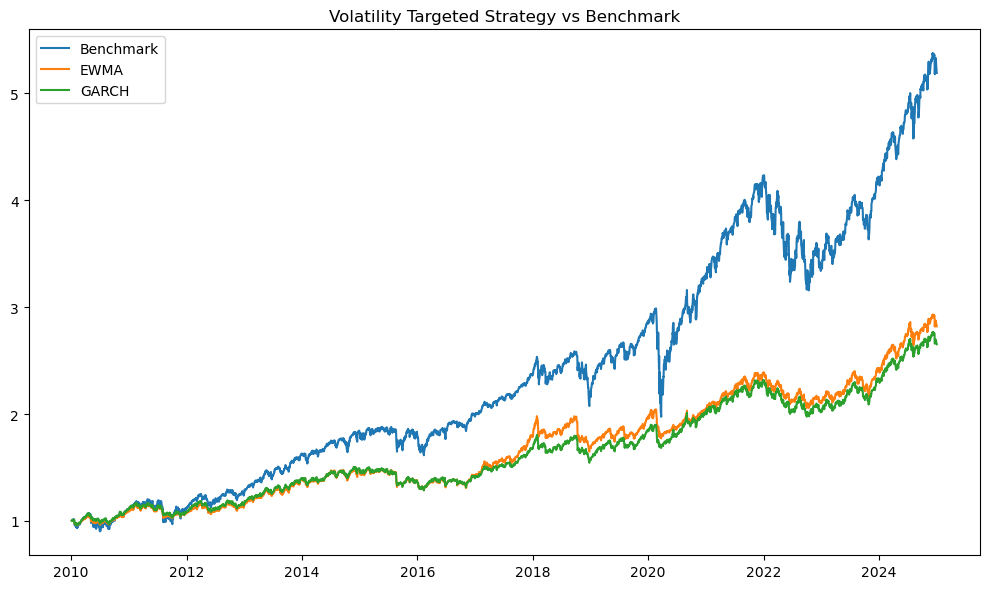

In [11]:
# plots
plt.figure(figsize=(10,6))
plt.plot(df.index, df['cum_bench'], label='Benchmark')
plt.plot(df.index, df['cum_ewma'], label='EWMA')
plt.plot(df.index, df['cum_garch'], label='GARCH')
plt.title('Volatility Targeted Strategy vs Benchmark')
plt.legend(); plt.tight_layout(); plt.show()

os.makedirs('results', exist_ok=True)
df.to_csv('results/vol_targeting_results.csv')